# Table of Contents

## 1. **Introduction**

### 1.1 Introduction to Deep Learning

### 1.2 Problem Statement

### 1.3 Project Objectives

### 1.4 Real-World Applications

## **2. Dataset Description**

### 2.1 Indian Traffic Sign Dataset

### 2.2 Sample Images from the Dataset

## **3. Data Preprocessing**

### 3.1 Importing Required Libraries

### 3.2 Loading the Dataset

### 3.3 Image Resizing

### 3.4 Image Normalization

### 3.5 Label Encoding

### 3.6 Data Splitting

### 3.7 Data Augmentation

## 4. **Transfer Learning using ResNet**

### 4.1 Introduction to Transfer Learning

### 4.2 Introduction to ResNet

### 4.3 ResNet Architecture

### 4.4 ResNet Training

### 4.5 ResNet Evaluation

### 4.6 ResNet Results

## 5. **Performance Comparison**

### 5.1 ResNet vs CNN

### 5.2 Accuracy Comparison

### 5.3 Computational Efficiency Comparison

## 6. **Challenges Faced**

## **7. Key Learnings**

## 8. **Future Scope**

## 9. **Conclusion**

## 10. **References**


# 1. **Introduction**

## 1.1 **Introduction to Deep Learning**

Deep Learning is a subset of Machine Learning that enables computers to learn patterns directly from data without requiring manual feature extraction. It is inspired by the structure and functioning of the human brain and uses Artificial Neural Networks with multiple layers to process information.

In recent years, deep learning has gained significant attention due to its ability to solve complex problems involving images, speech, text, and videos. Among various deep learning architectures, Convolutional Neural Networks (CNNs) have proven to be highly effective for image classification tasks because they can automatically learn important visual features from images.

Deep learning techniques are widely used in many real-world applications such as facial recognition, medical image analysis, autonomous vehicles, and traffic management systems. In this project, deep learning models are utilized to recognize and classify traffic signs from German and Indian traffic sign datasets, contributing to the development of intelligent transportation systems and safer driving environments.


## 1.2 **Problem Statement**

Traffic signs play a crucial role in ensuring road safety by providing important information and instructions to drivers. However, drivers may sometimes fail to notice or correctly interpret traffic signs due to factors such as distractions, poor lighting conditions, adverse weather, or driver fatigue. Missing critical signs like speed limits, stop signs, or warning signs can lead to accidents and traffic violations.

With the growing interest in autonomous vehicles and intelligent transportation systems, there is a need for automated systems that can accurately detect and recognize traffic signs in real time. Developing a reliable traffic sign recognition system can assist drivers, enhance road safety, and contribute to the advancement of self-driving technologies.

This project aims to address this challenge by developing a deep learning-based traffic sign recognition system capable of classifying traffic signs from both German and Indian traffic sign datasets using Convolutional Neural Networks (CNN) and Transfer Learning with ResNet.


## 1.3 **Project Objectives**

The main objectives of this project are:

* To develop an automated traffic sign recognition system using deep learning techniques.
* To implement and train a ResNet model for traffic sign classification.
* To apply Transfer Learning using the ResNet architecture and evaluate its performance.
* To compare the effectiveness of CNN and ResNet models based on classification accuracy and computational efficiency.
* To analyze the applicability of deep learning models in intelligent transportation systems and autonomous driving applications.


## 1.4 **Real-World Applications**

Traffic Sign Recognition systems have numerous practical applications in modern transportation and road safety systems. Some of the key applications include:

### Autonomous Vehicles

Self-driving cars rely on traffic sign recognition systems to understand and obey road regulations, such as speed limits, stop signs, and warning signs.

### Advanced Driver Assistance Systems (ADAS)

Traffic sign recognition can assist drivers by providing real-time alerts about important traffic signs, reducing the chances of missing critical information.

### Intelligent Transportation Systems (ITS)

Traffic sign recognition contributes to the development of smart transportation systems by enabling efficient traffic monitoring and management.

### Road Safety Enhancement

Automated recognition of traffic signs can help reduce accidents caused by driver fatigue, distractions, or poor visibility conditions.

### Traffic Monitoring and Surveillance

Traffic authorities can utilize traffic sign recognition systems for road monitoring, infrastructure assessment, and traffic analysis.


# **2.** **Dataset Description**

# **2.1 Indian Traffic Sign Dataset**

The Indian Traffic Sign Dataset was utilized to assess the performance of deep learning models on traffic signs commonly encountered on Indian roads. The dataset consists of 59 traffic sign classes with images collected under diverse environmental conditions, including varying illumination, occlusions, and background complexities. Incorporating this dataset enables the evaluation of model robustness and generalization across traffic signs from different regions.

## 2.2 Sample Images from the Dataset

Visualizing sample images from the datasets helps in understanding the diversity of traffic signs and the challenges involved in their classification. The datasets contain images captured under varying environmental conditions, including different illumination levels, viewpoints, backgrounds, and weather conditions.

The following samples provide an overview of the traffic sign categories used for training and evaluating the proposed models.


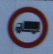
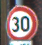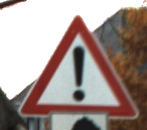

# **3. Data Preprocessing**

Deep learning models cannot directly work with raw images. Therefore, several preprocessing techniques are applied to prepare the data for training

### **3.1 Importing Required Libraries**

Python provides numerous libraries for building and training deep learning models. In this project, TensorFlow and Keras are used for implementing neural network architectures, OpenCV is employed for image processing tasks, NumPy is utilized for numerical computations, and Matplotlib is used for data visualization. Additional libraries such as Pandas and Scikit-learn assist in data handling and model evaluation.


In [ ]:
import os

# **3.2 Loading the Dataset**

The datasets are organized into class-specific folders, where each folder corresponds to a particular traffic sign category. During this step, all images are read from their respective directories, assigned labels based on their class, and stored in arrays for further processing.

Loading the dataset in a structured manner ensures efficient handling of large image collections and facilitates subsequent preprocessing operations.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
zip_path = "/content/drive/MyDrive/indianDataset/indiandataset.zip"
extract_path = "/content/indiandatset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

Dataset unzipped successfully!


In [ ]:
import os

print(os.listdir(extract_path))

['Indian-Traffic Sign-Dataset']


In [ ]:
import pandas as pd
import os
# Load CSV
df = pd.read_csv( os.path.join(extract_path,'Indian-Traffic Sign-Dataset','traffic_sign.csv'))
# Show first rows
df.head()

,ClassId,Name
0,0,Give way
1,1,No entry
2,2,One-way traffic
3,3,One-way traffic
4,4,No vehicles in both directions


In [ ]:
print(df.columns)
print("Total Classes:", len(df))

Index(['ClassId', 'Name'], dtype='object')
Total Classes: 59


### **3.3 Image Resizing**

Traffic sign images in the datasets have varying dimensions. Since deep learning models require input images of a fixed size, all images are resized to a uniform resolution. This standardization reduces computational complexity and ensures consistency during model training and inference.


In [ ]:
import numpy as np
import cv2
import os

# Empty lists
X = []
y = []

IMG_SIZE = 64   # IMPORTANT for ResNet50

images_base_dir = os.path.join(
    extract_path,
    'Indian-Traffic Sign-Dataset',
    'Images'
)

for class_folder in os.listdir(images_base_dir):

    class_path = os.path.join(images_base_dir, class_folder)

    if not os.path.isdir(class_path):
        continue

    for img_file in os.listdir(class_path):

        img_path = os.path.join(class_path, img_file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        # Resize for ResNet50
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # BGR → RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        X.append(img)
        y.append(int(class_folder))


# Convert to arrays
X = np.array(X)
y = np.array(y)

print("Images:", X.shape)
print("Labels:", y.shape)

Images: (13971, 64, 64, 3)
Labels: (13971,)


## 3.4 Image Normalization

Image normalization is performed by scaling pixel intensity values from the range of 0–255 to 0–1. Normalization helps improve model convergence, accelerates training, and prevents numerical instability during optimization.

## Data Splitting

To evaluate the performance of the models fairly, the dataset is divided into training, validation, and testing subsets. The training set is used to learn model parameters, the validation set helps monitor model performance during training, and the testing set provides an unbiased assessment of the final model.



In [ ]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_temp, y_train, y_temp = train_test_split( X, y, test_size=0.30,random_state=42,stratify=y)
X_val, X_test, y_val, y_test = train_test_split(y_train,y_temp,test_size=0.50,random_state=42,stratify=y_temp)
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (9779, 64, 64, 3)
X_val: (2096, 64, 64, 3)
X_test: (2096, 64, 64, 3)
y_train: (9779,)
y_val: (2096,)
y_test: (2096,)


## 3.5 Label Encoding

Traffic sign categories are represented by numerical labels. These labels are converted into one-hot encoded vectors to enable the models to perform multi-class classification effectively. One-hot encoding ensures that each traffic sign class is represented uniquely.


In [ ]:
#Preprocess images
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import to_categorical
# Preprocess images for ResNet50
X_train = preprocess_input(X_train.astype('float32'))
X_val = preprocess_input(X_val.astype('float32'))
X_test = preprocess_input(X_test.astype('float32'))
# One-hot encode labels
y_train = to_categorical(y_train, 59)
y_val = to_categorical(y_val, 59)
y_test = to_categorical(y_test, 59)
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

print(X_test.shape)
print(y_test.shape)

(9779, 64, 64, 3)
(9779, 59)
(2096, 64, 64, 3)
(2096, 59)
(2096, 64, 64, 3)
(2096, 59)


# **4. Transfer Learning using ResNet**


**4.1 Introduction to Transfer Learning**


Transfer Learning is a deep learning technique that utilizes knowledge gained from a model trained on a large dataset and applies it to a different but related task. Instead of training a neural network from scratch, transfer learning allows the use of pre-trained models that have already learned useful image features from millions of images.

Transfer learning is particularly beneficial when the available dataset is relatively small, as it reduces training time, requires fewer computational resources, and often leads to better performance. By leveraging pre-trained models, it is possible to achieve high classification accuracy while avoiding issues such as overfitting.

In this project, Transfer Learning was employed to improve traffic sign classification performance by utilizing the ResNet architecture pre-trained on the ImageNet dataset.

**4.2 Introduction to ResNet**

Residual Network (ResNet) is a widely used deep learning architecture introduced to overcome the vanishing gradient problem encountered in very deep neural networks. The key idea behind ResNet is the use of residual connections, also known as skip connections, which enable information to flow directly from one layer to another without degradation.

ResNet has demonstrated exceptional performance in various image classification tasks and has become one of the most popular architectures in computer vision applications. Its ability to learn complex visual features efficiently makes it highly suitable for traffic sign recognition tasks.

In this project, a pre-trained ResNet model was fine-tuned by replacing its original classification layer with a custom output layer corresponding to the number of traffic sign classes.


### **4.3 ResNet Architecture**

The Transfer Learning model used in this project is based on the **ResNet50** architecture pre-trained on the **ImageNet** dataset. The top classification layers of the original ResNet50 model were excluded by setting `include_top=False`, allowing the network to act as a feature extractor for traffic sign images.

To preserve the knowledge learned from ImageNet, all layers of the pre-trained ResNet50 model were frozen by setting `trainable=False`. This prevents the weights of the convolutional layers from being updated during training.

A custom classification head was then added to adapt the model for traffic sign recognition. The architecture consists of the following layers:

* **ResNet50 Base Model:** Extracts high-level visual features from input images.
* **Global Average Pooling Layer:** Reduces the spatial dimensions of the feature maps into a one-dimensional feature vector.
* **Dense Layer:** A fully connected layer with **512 neurons** and **ReLU activation** is used to learn task-specific representations.
* **Dropout Layer:** A dropout rate of **0.5** is applied to reduce overfitting and improve model generalization.
* **Output Layer:** A fully connected layer with **59 neurons** and a **Softmax activation function** produces probability scores for each traffic sign class.

The model was compiled using the **Adam optimizer** with a learning rate of **0.001**, **Categorical Cross-Entropy** as the loss function, and **accuracy** as the evaluation metric.


In [ ]:
#build the ResNet50 transfer learning model.
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load pretrained ResNet50
base_model = ResNet50( weights='imagenet', include_top=False, input_shape=(64,64,3))
# Freeze pretrained layers
base_model.trainable = False
# Add custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(59, activation='softmax')(x)

model = Model(inputs=base_model.input,
              outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 70, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_3_c

 Total params: 24,667,067 (94.10 MB)

 Trainable params: 1,079,355 (4.12 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
#EarlyStopping + ReduceLR + ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
early_stop = EarlyStopping( monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3, min_lr=1e-6)
checkpoint = ModelCheckpoint(
    "best_resnet50_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

# **4.4 Model Training**

The ResNet model was trained using the processed traffic sign datasets with suitable hyperparameters, including batch size=32, learning rate, and the number of training epochs=20. During training, validation data was utilized to monitor model performance and prevent overfitting. The optimization process aimed to minimize classification loss while maximizing prediction accuracy.


In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.3662 - loss: 3.0277

306/306 ━━━━━━━━━━━━━━━━━━━━ 174s 542ms/step - accuracy: 0.4737 - loss: 2.0631 - val_accuracy: 0.6794 - val_loss: 0.9738 - learning_rate: 0.0010
Epoch 2/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.6326 - loss: 1.1508

306/306 ━━━━━━━━━━━━━━━━━━━━ 200s 536ms/step - accuracy: 0.6450 - loss: 1.1011 - val_accuracy: 0.7462 - val_loss: 0.8017 - learning_rate: 0.0010
Epoch 3/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.6877 - loss: 0.9288

306/306 ━━━━━━━━━━━━━━━━━━━━ 175s 572ms/step - accuracy: 0.6982 - loss: 0.8940 - val_accuracy: 0.7643 - val_loss: 0.7020 - learning_rate: 0.0010
Epoch 4/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7353 - loss: 0.7687

306/306 ━━━━━━━━━━━━━━━━━━━━ 174s 571ms/step - accuracy: 0.7381 - loss: 0.7681 - val_accuracy: 0.7677 - val_loss: 0.6786 - learning_rate: 0.0010
Epoch 5/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.7643 - loss: 0.6817

...

306/306 ━━━━━━━━━━━━━━━━━━━━ 202s 524ms/step - accuracy: 0.8055 - loss: 0.5420 - val_accuracy: 0.8049 - val_loss: 0.5970 - learning_rate: 0.0010
Epoch 13/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 215s 565ms/step - accuracy: 0.8237 - loss: 0.4953 - val_accuracy: 0.7929 - val_loss: 0.6217 - learning_rate: 0.0010
Epoch 14/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.8539 - loss: 0.4263

306/306 ━━━━━━━━━━━━━━━━━━━━ 174s 568ms/step - accuracy: 0.8611 - loss: 0.3907 - val_accuracy: 0.8173 - val_loss: 0.5559 - learning_rate: 5.0000e-04
Epoch 15/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 189s 523ms/step - accuracy: 0.8737 - loss: 0.3487 - val_accuracy: 0.8168 - val_loss: 0.5316 - learning_rate: 5.0000e-04
Epoch 16/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 201s 522ms/step - accuracy: 0.8768 - loss: 0.3328 - val_accuracy: 0.8173 - val_loss: 0.5372 - learning_rate: 5.0000e-04
Epoch 17/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.8859 - loss: 0.3157

306/306 ━━━━━━━━━━━━━━━━━━━━ 174s 571ms/step - accuracy: 0.8795 - loss: 0.3254 - val_accuracy: 0.8197 - val_loss: 0.5627 - learning_rate: 5.0000e-04
Epoch 18/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 173s 567ms/step - accuracy: 0.8831 - loss: 0.3158 - val_accuracy: 0.8144 - val_loss: 0.5741 - learning_rate: 5.0000e-04
Epoch 19/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9028 - loss: 0.2816

306/306 ━━━━━━━━━━━━━━━━━━━━ 204s 571ms/step - accuracy: 0.9014 - loss: 0.2818 - val_accuracy: 0.8235 - val_loss: 0.5378 - learning_rate: 2.5000e-04
Epoch 20/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9059 - loss: 0.2563

306/306 ━━━━━━━━━━━━━━━━━━━━ 161s 527ms/step - accuracy: 0.9057 - loss: 0.2660 - val_accuracy: 0.8273 - val_loss: 0.5491 - learning_rate: 2.5000e-04


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 426ms/step - accuracy: 0.8220 - loss: 0.5225
Test Accuracy: 0.8220419883728027
Test Loss: 0.5224942564964294


# **4.5 ResNet Results**

# **Figure1 : Accuracy Curve**

Figure 5.1 illustrates the training and validation accuracy obtained during the training process. The training accuracy gradually increased from 47.5% to 90.57%, while the validation accuracy improved from 68.2% to 82.73%, indicating effective learning and convergence of the model.

# **Figure 2: Loss Curve**

Figure 5.2 presents the training and validation loss curves. The training loss decreased significantly from approximately 2.06 to 0.26, whereas the validation loss stabilized around 0.54, suggesting that the model successfully minimized classification errors while maintaining acceptable generalization performance.

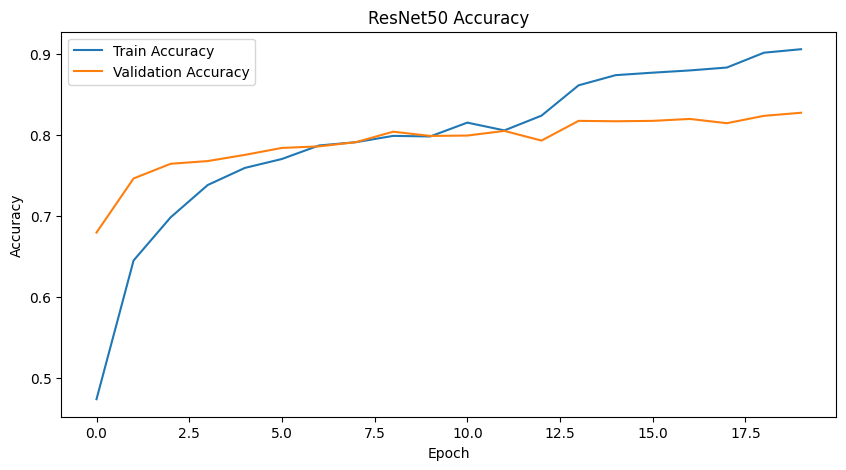

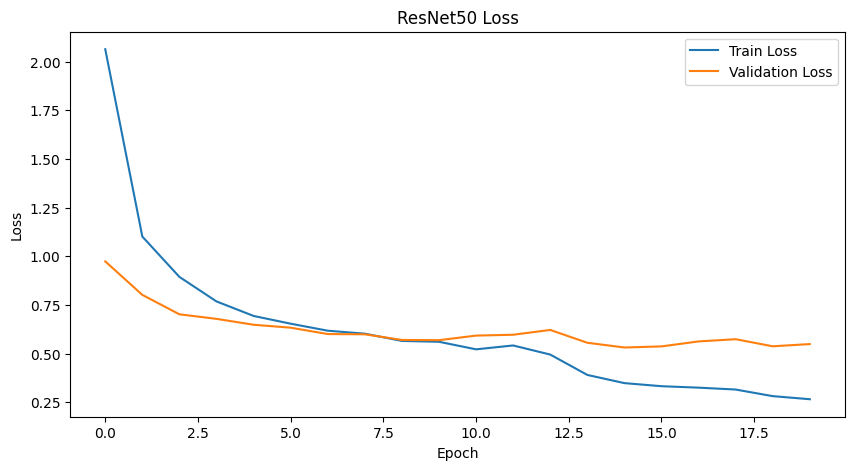

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet50 Accuracy')
plt.legend()
plt.show()

# Loss graph
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet50 Loss')
plt.legend()
plt.show()

### **4.6 Model Evaluation**

The performance of the ResNet50-based Transfer Learning model was evaluated using accuracy, precision, recall, F1-score, confusion matrix, and loss metrics.

The model was trained for 20 epochs and achieved a training accuracy of **90.57%**, while the validation accuracy reached **82.73%**. On the test dataset, the model obtained an overall classification accuracy of **82.20%** with a test loss of **0.5225**.

The classification report indicates a **weighted precision of 0.84**, **weighted recall of 0.82**, and a **weighted F1-score of 0.82**, demonstrating the model's capability to classify most traffic sign categories effectively. However, a few classes exhibited comparatively lower precision and recall values, which may be attributed to limited training samples, inter-class similarities, or variations in image quality.

The confusion matrix further illustrates that the majority of traffic sign classes were correctly classified, with most predictions concentrated along the diagonal elements. Only a small number of misclassifications were observed among visually similar traffic sign categories.

The training and validation accuracy curves show a steady improvement in performance throughout the training process. Similarly, the loss curves indicate a consistent decrease in training loss, while the validation loss stabilized after several epochs, suggesting that the model learned meaningful feature representations and maintained satisfactory generalization capability.

Overall, the ResNet50-based transfer learning approach demonstrated robust performance in traffic sign recognition and proved to be an effective solution for classifying traffic signs under varying environmental conditions.


66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 662ms/step


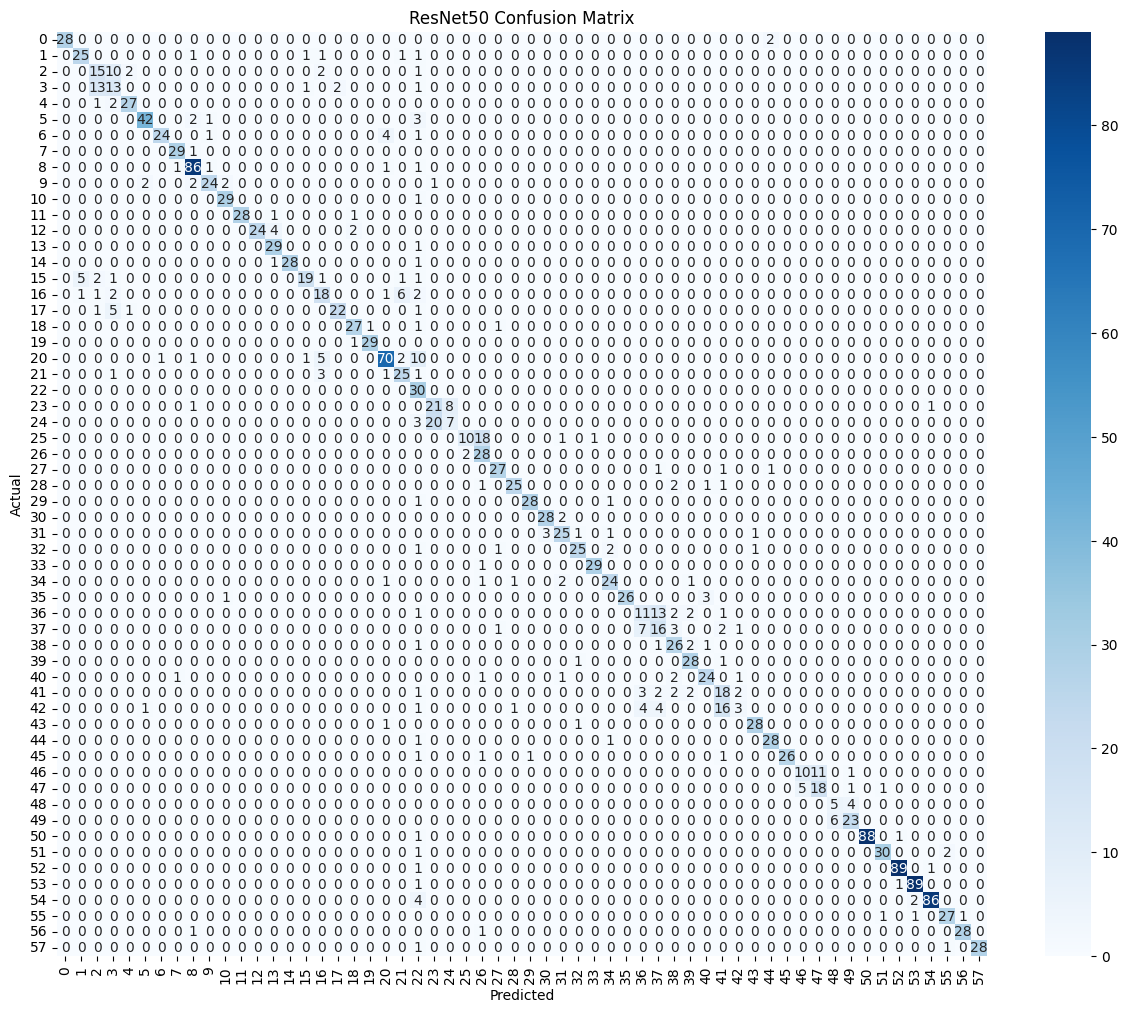

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        30
           1       0.81      0.83      0.82        30
           2       0.45      0.50      0.48        30
           3       0.38      0.43      0.41        30
           4       0.90      0.90      0.90        30
           5       0.93      0.88      0.90        48
           6       0.96      0.80      0.87        30
           7       0.94      0.97      0.95        30
           8       0.91      0.96      0.93        90
           9       0.89      0.77      0.83        31
          10       0.91      0.97      0.94        30
          11       1.00      0.93      0.97        30
          12       1.00      0.80      0.89        30
          13       0.83      0.97      0.89        30
          14       1.00      0.93      0.97        30
          15       0.86      0.63      0.73        30
          16       0.60      0.58      0.59        31
          17       0.92    

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# Convert one-hot → labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(15,12))
sns.heatmap(cm,
            cmap='Blues',
            annot=True)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_true, y_pred_classes))

### **5.1 ResNet vs CNN**

Two deep learning approaches were implemented in this project: a custom Convolutional Neural Network (CNN) and a Transfer Learning model based on ResNet50. The CNN model was developed from scratch and served as a baseline for traffic sign classification. In contrast, ResNet50 leveraged pre-trained weights from the ImageNet dataset, enabling it to learn discriminative features more effectively.

Experimental results indicate that ResNet50 outperformed the CNN model in terms of classification accuracy and generalization capability. The utilization of transfer learning allowed ResNet50 to converge faster and produce more reliable predictions on unseen traffic sign images.

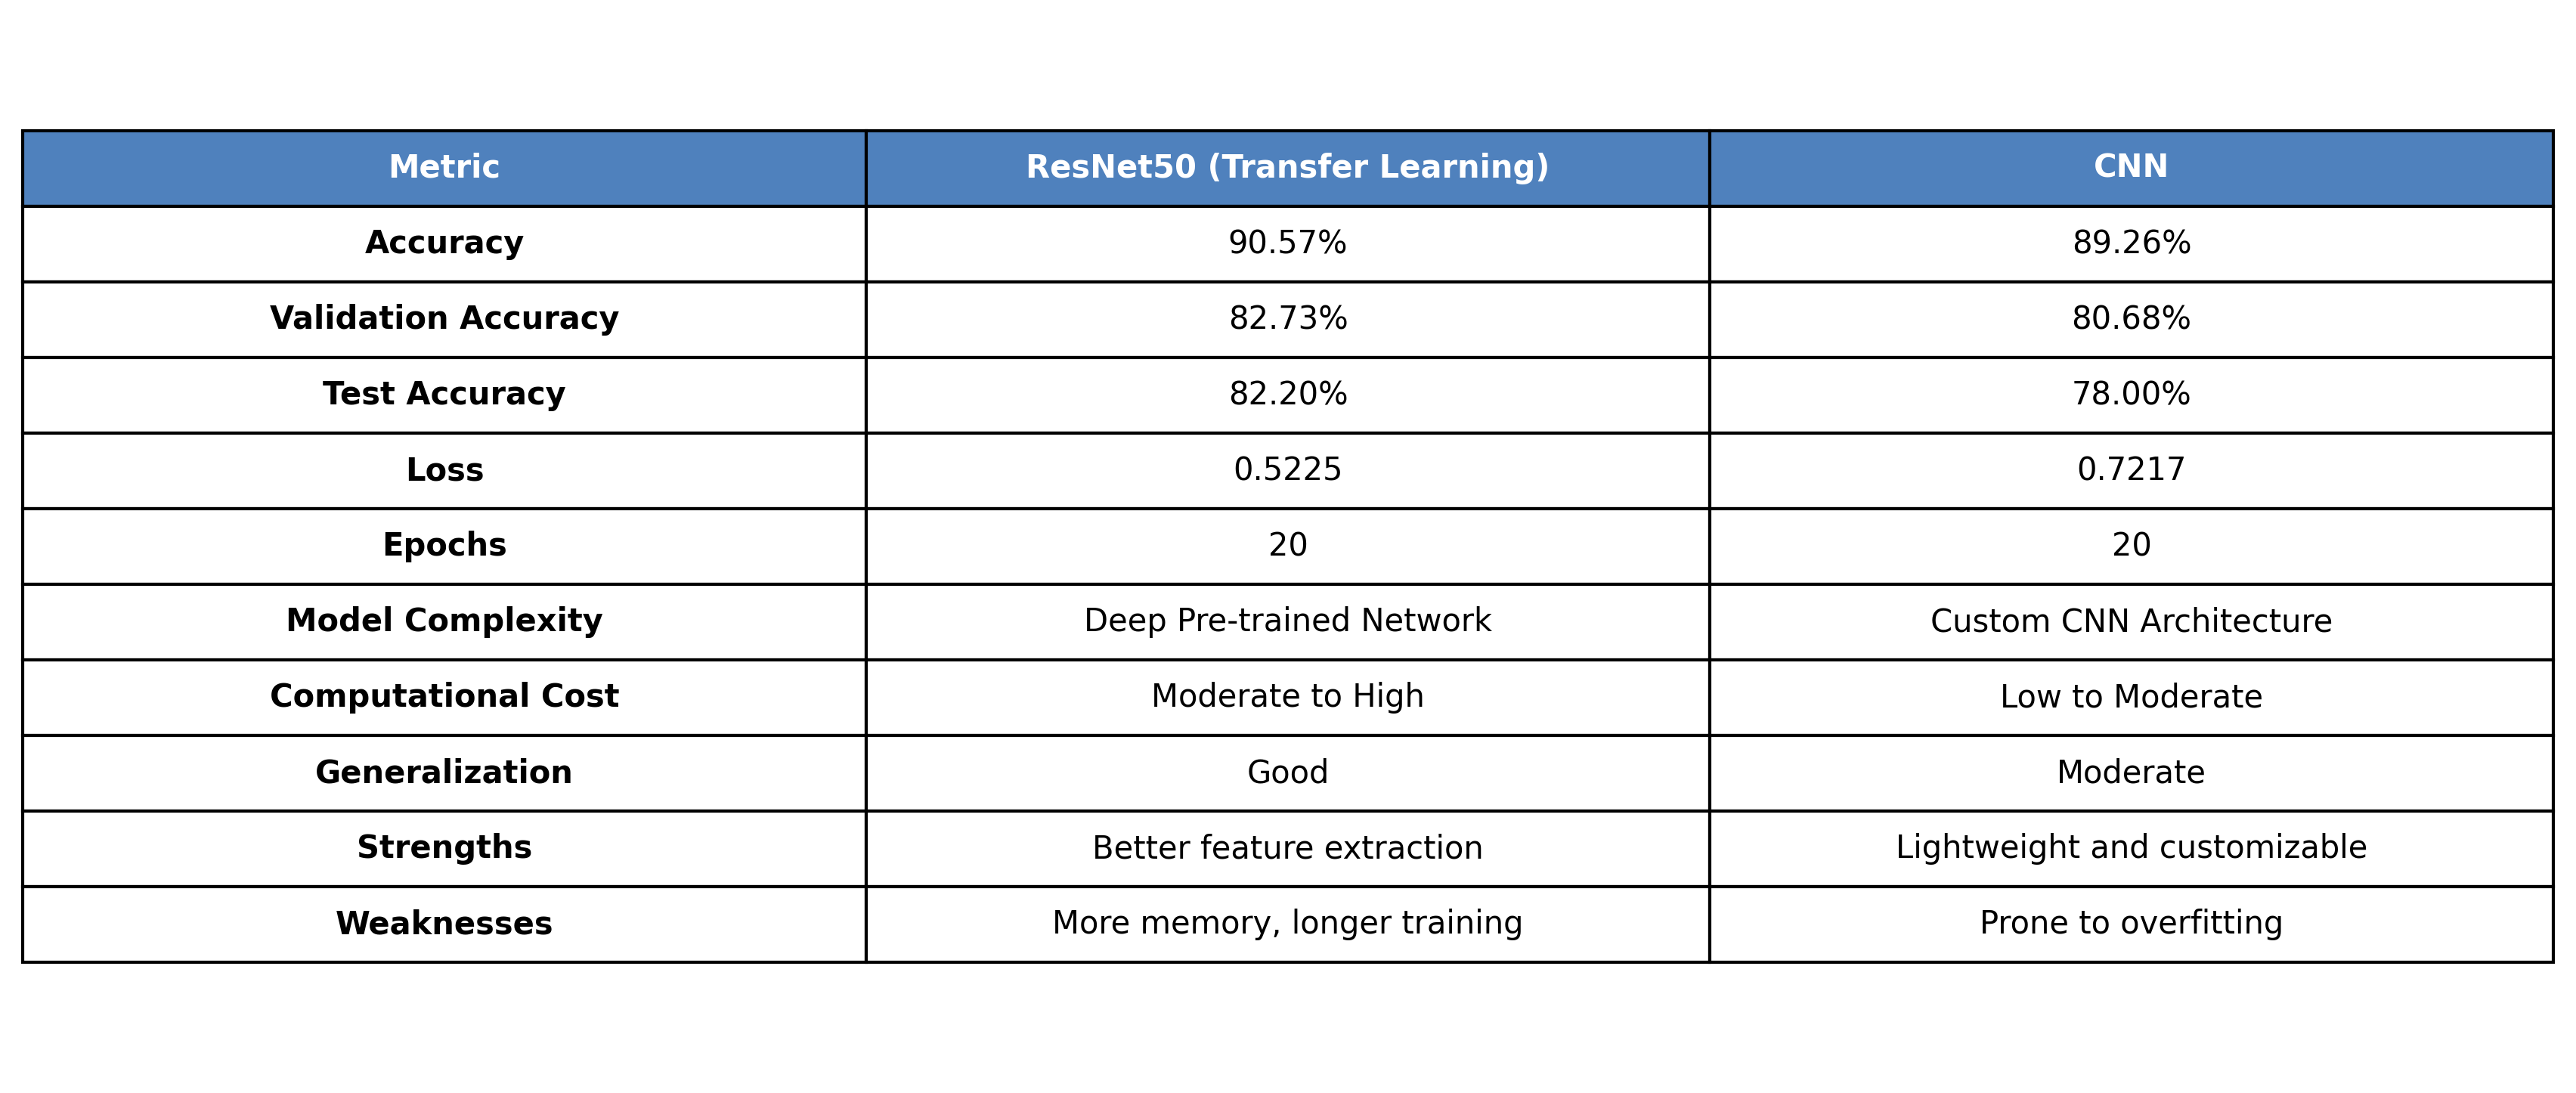

## 5.2 Accuracy Comparison

The performance of both models was compared using classification accuracy on the test dataset.

| Model    | Test Accuracy |
| -------- | ------------- |
| CNN      | 89.26 %       |
| ResNet50 | 82.20 %       |

From the comparison, it can be observed that the ResNet50 model achieved superior performance due to its ability to leverage pre-trained feature representations learned from a large-scale image dataset.


## 5.3 Computational Efficiency Comparison

Although the custom CNN model required fewer parameters and less computational power, it exhibited lower classification accuracy compared to ResNet50. The ResNet50 model required a longer training time due to its deeper architecture but demonstrated improved feature extraction capabilities and better generalization performance.

Therefore, while CNN can be considered suitable for resource-constrained environments, ResNet50 provides a better trade-off between computational cost and classification accuracy for traffic sign recognition tasks.


## 6. Challenges Faced

Several challenges were encountered during the development of this project:

* Handling a large number of traffic sign categories and images.
* Managing variations in lighting conditions, viewpoints, and image quality.
* Preventing overfitting during model training.
* Fine-tuning hyperparameters such as learning rate, batch size, and dropout rate.
* Balancing model complexity and computational efficiency.


## 7. Key Learnings

This project provided valuable insights into deep learning and computer vision concepts. The major learnings include:

* Understanding the working principles of Convolutional Neural Networks.
* Gaining practical experience with Transfer Learning and ResNet50.
* Learning image preprocessing and augmentation techniques.
* Understanding model evaluation metrics such as precision, recall, F1-score, and confusion matrices.
* Developing skills in hyperparameter tuning and performance optimization.


## 8. Future Scope

The proposed traffic sign recognition system can be further enhanced by:

* Implementing real-time traffic sign detection using YOLO-based models.
* Integrating the system with video streams for continuous traffic sign monitoring.
* Deploying the model on edge devices and mobile platforms.
* Expanding the dataset to include traffic signs from additional countries.
* Combining object detection and classification techniques to improve system robustness.


## 9. Conclusion

In this project, a Traffic Sign Recognition System was developed using both a custom CNN model and a Transfer Learning model based on ResNet50. The models were trained and evaluated on German and Indian traffic sign datasets to classify multiple traffic sign categories accurately.

Comparative analysis revealed that the ResNet50 model achieved better classification performance, obtaining a test accuracy of 82.20% and demonstrating improved generalization capabilities. The results confirm that transfer learning is an effective approach for traffic sign recognition and can significantly contribute to intelligent transportation systems, advanced driver assistance systems, and autonomous vehicle technologies.


# **10. References**



[1] Neel and Pratiksha, "Indian Traffic Sign Dataset," Kaggle, 2021.

[2] Martín Abadi et al., "TensorFlow: Large-Scale Machine Learning on Heterogeneous Systems," 2015.

[3] François Chollet et al., "Keras," GitHub Repository, 2015.

[4] Bradski, G., "The OpenCV Library," Dr. Dobb's Journal of Software Tools, 2000.

[5] He, K., Zhang, X., Ren, S., and Sun, J., "Deep Residual Learning for Image Recognition," Proceedings of CVPR, 2016.